# Thermal Video Viewer
**Sorgente:** tutti i file `.seq` trovati in `Thermal_videos/`

Questo notebook legge e visualizza i file termici `.seq` prodotti dalla telecamera FLIR.
Richiede il modulo `fnv` installato dal **FLIR Science File SDK** (`Systems-XXXX.whl`).

## 0 · Installazione (solo la prima volta)
Assicurati di aver installato il FLIR Science File SDK e le librerie necessarie:
```bash
# Installa il FLIR Science File SDK (adatta il path al tuo sistema)
pip install "C:\Files\Systems-2024.7.1-cp311-win_amd64.whl"

# Librerie standard
pip install numpy matplotlib opencv-python pillow tqdm ipywidgets
```

In [1]:
%matplotlib inline

# widget Matplotlib in VS Code e spesso instabile; usiamo ipywidgets.Image
import json
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import BytesIO
from pathlib import Path

import fnv
import fnv.file
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from PIL import Image
from tqdm.auto import tqdm

## 1 · Ricerca automatica file `.seq`

In [2]:
from config import DATA_DIR

DATA_PATH = Path(DATA_DIR)
SEQ_FILES = sorted(DATA_PATH.glob("*.seq"))

if not SEQ_FILES:
    raise FileNotFoundError(f"Nessun file .seq trovato in: {DATA_PATH}")

print(f"Trovati {len(SEQ_FILES)} file .seq in {DATA_PATH}:")
for p in SEQ_FILES:
    print(f"- {p.name}")

Trovati 1 file .seq in C:\Users\tomga\Desktop\ROI_study\Thermal_videos:
- Rec-G3_std.seq


## 2 · Caricamento dei frame

In [3]:
N_CORES = 6  # cambiare in base al proprio PC

def _cache_dir() -> Path:
    cache_dir = Path(DATA_DIR) / "_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    return cache_dir

def _cache_key(filepath: str) -> str:
    path = Path(filepath)
    stat = path.stat()
    return f"{path.stem}_{stat.st_size}_{int(stat.st_mtime)}"

def _cache_paths(filepath: str):
    key = _cache_key(filepath)
    cache_dir = _cache_dir()
    return cache_dir / f"{key}.npy", cache_dir / f"{key}.json"

def _read_seq_chunk(filepath: str, frame_indices: np.ndarray, height: int, width: int) -> np.ndarray:
    im = fnv.file.ImagerFile(filepath)
    im.unit = fnv.Unit.TEMPERATURE_FACTORY
    im.temp_type = fnv.TempType.CELSIUS

    chunk = np.empty((len(frame_indices), height, width), dtype=np.float32)
    for out_idx, frame_idx in enumerate(frame_indices):
        im.get_frame(int(frame_idx))
        chunk[out_idx] = np.asarray(im.final, dtype=np.float32).reshape(height, width)

    return chunk

def load_seq_parallel(filepath: str, n_cores: int = N_CORES) -> np.ndarray:
    meta_im = fnv.file.ImagerFile(filepath)
    meta_im.unit = fnv.Unit.TEMPERATURE_FACTORY
    meta_im.temp_type = fnv.TempType.CELSIUS

    n_frames = int(meta_im.num_frames)
    height = int(meta_im.height)
    width = int(meta_im.width)

    n_workers = max(1, min(int(n_cores), n_frames))
    frame_chunks = [chunk for chunk in np.array_split(np.arange(n_frames), n_workers) if len(chunk) > 0]

    results = [None] * len(frame_chunks)

    with ThreadPoolExecutor(max_workers=len(frame_chunks)) as executor:
        future_map = {
            executor.submit(_read_seq_chunk, filepath, chunk, height, width): idx
            for idx, chunk in enumerate(frame_chunks)
        }

        with tqdm(total=n_frames, desc=f"Caricamento {Path(filepath).name}", unit="frame") as pbar:
            for future in as_completed(future_map):
                chunk_idx = future_map[future]
                chunk = future.result()
                results[chunk_idx] = chunk
                pbar.update(chunk.shape[0])

    return np.concatenate(results, axis=0)

def _save_cache(filepath: str, frames: np.ndarray):
    path = Path(filepath)
    npy_path, json_path = _cache_paths(filepath)
    stat = path.stat()

    meta = {
        "source_file": path.name,
        "n_frames": int(frames.shape[0]),
        "height": int(frames.shape[1]),
        "width": int(frames.shape[2]),
        "min_celsius": float(frames.min()),
        "max_celsius": float(frames.max()),
        "source_size": int(stat.st_size),
        "source_mtime": int(stat.st_mtime),
    }

    np.save(npy_path, frames.astype(np.float32, copy=False), allow_pickle=False)
    json_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    print(f"Cache salvata: {npy_path.name}")
    return meta

def _load_cache(filepath: str):
    npy_path, json_path = _cache_paths(filepath)
    if not npy_path.exists() or not json_path.exists():
        return None, None

    # mmap_mode evita di caricare tutto il file in RAM
    frames = np.load(npy_path, mmap_mode="r", allow_pickle=False)
    meta = json.loads(json_path.read_text(encoding="utf-8"))
    print(f"Cache hit (mmap): {Path(filepath).name}")
    return frames, meta

def load_seq_cached(filepath: str, n_cores: int = N_CORES):
    frames, meta = _load_cache(filepath)
    if frames is not None:
        return frames, meta

    print(f"Cache miss: {Path(filepath).name}")
    frames = load_seq_parallel(filepath, n_cores=n_cores)
    meta = _save_cache(filepath, frames)

    # Riapriamo in mmap per ridurre pressione memoria nelle celle successive
    npy_path, _ = _cache_paths(filepath)
    del frames
    frames_mmap = np.load(npy_path, mmap_mode="r", allow_pickle=False)
    return frames_mmap, meta

## 3 · Normalizzazione globale
Come indicato nelle slide del corso, i valori di pixel vengono normalizzati rispetto al
**minimo e massimo globali** calcolati su **tutti i video `.seq` caricati** nell'intervallo [0, 255].

In [4]:
video_data = {}

for seq_path in SEQ_FILES:
    frames, meta = load_seq_cached(str(seq_path), n_cores=N_CORES)
    video_data[seq_path.stem] = {
        "path": str(seq_path),
        "frames": frames,
        "meta": meta,
    }

cache_dir = Path(DATA_DIR) / "_cache"
cache_dir.mkdir(parents=True, exist_ok=True)
global_meta_path = cache_dir / "global_meta.json"

def _build_global_meta(video_data: dict) -> dict:
    all_min = min(float(item["frames"].min()) for item in video_data.values())
    all_max = max(float(item["frames"].max()) for item in video_data.values())
    return {
        "global_min": all_min,
        "global_max": all_max,
        "video_count": int(len(video_data)),
        "video_names": sorted(video_data.keys()),
    }

global_meta = None
if global_meta_path.exists():
    try:
        global_meta = json.loads(global_meta_path.read_text(encoding="utf-8"))
        if "global_min" not in global_meta or "global_max" not in global_meta:
            global_meta = None
    except Exception:
        global_meta = None

if global_meta is None:
    global_meta = _build_global_meta(video_data)
    global_meta_path.write_text(json.dumps(global_meta, indent=2), encoding="utf-8")
    print(f"Global metadata creato: {global_meta_path.resolve()}")
else:
    print(f"Global metadata caricato da: {global_meta_path.resolve()}")

global_min = float(global_meta["global_min"])
global_max = float(global_meta["global_max"])

def normalize_frame(frame: np.ndarray, global_min: float, global_max: float) -> np.ndarray:
    """Normalizza un singolo frame in [0, 255] (uint8) senza allocare tutto il video."""
    if global_max == global_min:
        return np.zeros_like(frame, dtype=np.uint8)
    norm = (frame - global_min) / (global_max - global_min) * 255
    return np.clip(norm, 0, 255).astype(np.uint8)

VIDEO_NAMES = sorted(video_data.keys())
SELECTED_VIDEO = VIDEO_NAMES[0]
frames_selected = video_data[SELECTED_VIDEO]["frames"]

print("Riepilogo finale")
for name in VIDEO_NAMES:
    frames = video_data[name]["frames"]
    print(f"{name:<20}: {frames.shape}   min={frames.min():.1f}degC  max={frames.max():.1f}degC")
print(f"Range temperatura globale: [{global_min:.2f}, {global_max:.2f}] degC")
print("Nota: min/max globali vengono letti o creati in questa esecuzione.")

Cache miss: Rec-G3_std.seq


Caricamento Rec-G3_std.seq:   0%|          | 0/3397 [00:00<?, ?frame/s]

Cache salvata: Rec-G3_std_2096138326_1774018001.npy
Global metadata creato: C:\Users\tomga\Desktop\ROI_study\Thermal_videos\_cache\global_meta.json
Riepilogo finale
Rec-G3_std          : (3397, 480, 640)   min=40.1degC  max=180.2degC
Range temperatura globale: [40.10, 180.17] degC
Nota: min/max globali vengono letti o creati in questa esecuzione.


## 4 · Visualizzazione singolo frame (statica)

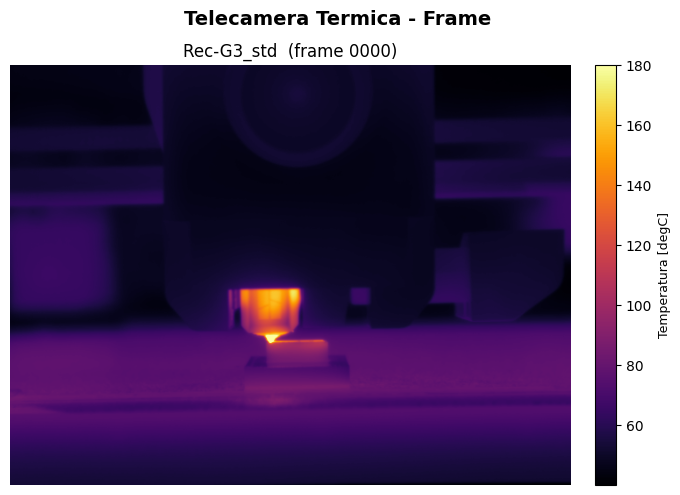

In [5]:
COLORMAP = "inferno"   # colormaps consigliati: inferno, hot, jet, plasma
FRAME_IDX = 0            # indice del frame da visualizzare
VIDEO_TO_SHOW = SELECTED_VIDEO

frames_to_show = video_data[VIDEO_TO_SHOW]["frames"]
if len(frames_to_show) == 0:
    raise ValueError(f"Il video {VIDEO_TO_SHOW} non contiene frame.")

frame_idx = min(FRAME_IDX, len(frames_to_show) - 1)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
fig.suptitle("Telecamera Termica - Frame", fontsize=14, fontweight="bold")

im = ax.imshow(
    frames_to_show[frame_idx],
    cmap=COLORMAP,
    vmin=global_min,
    vmax=global_max
)
ax.set_title(f"{VIDEO_TO_SHOW}  (frame {frame_idx:04d})")
ax.axis("off")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Temperatura [degC]", fontsize=9)

plt.tight_layout()
plt.show()

## 5 · Visualizzazione interattiva con slider + selezione video

In [6]:
COLORMAP = "inferno"
MAX_PREVIEW_WIDTH = 640

if not VIDEO_NAMES:
    raise ValueError("Nessun video disponibile da visualizzare.")

def _frame_to_png_bytes(frame: np.ndarray) -> bytes:
    norm = np.clip((frame - global_min) / (global_max - global_min + 1e-12), 0.0, 1.0)
    rgba = plt.get_cmap(COLORMAP)(norm, bytes=True)
    rgb = rgba[:, :, :3]
    with BytesIO() as buf:
        Image.fromarray(rgb, mode="RGB").save(buf, format="PNG")
        return buf.getvalue()

video_dropdown = widgets.Dropdown(
    options=VIDEO_NAMES,
    value=SELECTED_VIDEO,
    description="Video",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="60%")
)

frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=0,
    step=1,
    description="Frame",
    continuous_update=True,
    readout=True,
    readout_format="d",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="98%")
)

preview = widgets.Image(format="png", layout=widgets.Layout(max_width=f"{MAX_PREVIEW_WIDTH}px"))
title = widgets.HTML()

def _current_frames() -> np.ndarray:
    return video_data[video_dropdown.value]["frames"]

def _sync_slider_to_video():
    frames = _current_frames()
    frame_slider.max = max(0, len(frames) - 1)
    if frame_slider.value > frame_slider.max:
        frame_slider.value = frame_slider.max

def _update_view():
    frames = _current_frames()
    idx = int(frame_slider.value)
    if len(frames) == 0:
        title.value = f"<b>{video_dropdown.value}</b> - nessun frame"
        preview.value = b""
        return

    preview.value = _frame_to_png_bytes(frames[idx])
    title.value = f"<b>{video_dropdown.value}</b> - frame {idx:04d} / {len(frames) - 1:04d}"

def _on_video_change(change):
    if change["name"] == "value":
        _sync_slider_to_video()
        _update_view()

def _on_frame_change(change):
    if change["name"] == "value":
        _update_view()

video_dropdown.observe(_on_video_change, names="value")
frame_slider.observe(_on_frame_change, names="value")

_sync_slider_to_video()
_update_view()

ui = widgets.VBox([
    video_dropdown,
    frame_slider,
    title,
    preview,
])
display(ui)

## 6 · Plot profilo di temperatura (riga / colonna)

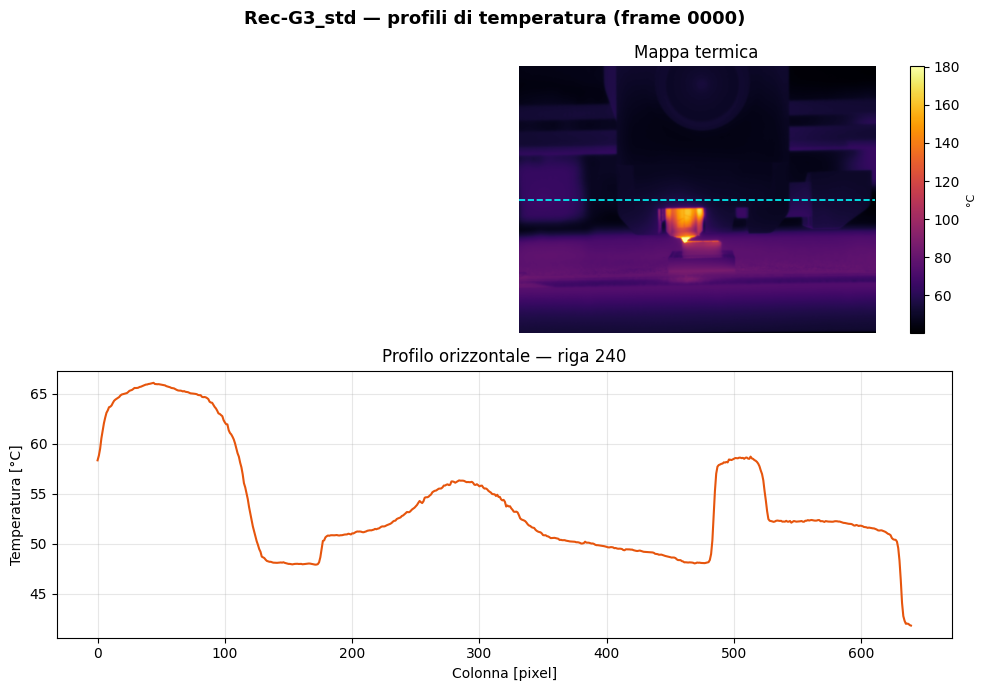

In [7]:
FRAME_IDX = 0
VIDEO_TO_PLOT = SELECTED_VIDEO

frames_plot = video_data[VIDEO_TO_PLOT]["frames"]
if len(frames_plot) == 0:
    raise ValueError(f"Il video {VIDEO_TO_PLOT} non contiene frame.")

frame_idx = min(FRAME_IDX, len(frames_plot) - 1)
frame = frames_plot[frame_idx]
ROW = frame.shape[0] // 2   # riga centrale
H, W = frame.shape

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
fig.suptitle(f"{VIDEO_TO_PLOT} — profili di temperatura (frame {frame_idx:04d})", fontsize=13, fontweight="bold")

# --- Mappa termica ---
im = axes[0].imshow(frame, cmap="inferno", vmin=global_min, vmax=global_max)
axes[0].axhline(ROW, color="cyan", lw=1.2, linestyle="--")
axes[0].set_title("Mappa termica")
axes[0].axis("off")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04).set_label("°C", fontsize=8)

# --- Profilo orizzontale ---
axes[1].plot(np.arange(W), frame[ROW, :], color="#e6550d", lw=1.5)
axes[1].set_xlabel("Colonna [pixel]")
axes[1].set_ylabel("Temperatura [°C]")
axes[1].set_title(f"Profilo orizzontale — riga {ROW}")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7 · Evoluzione temporale della temperatura media

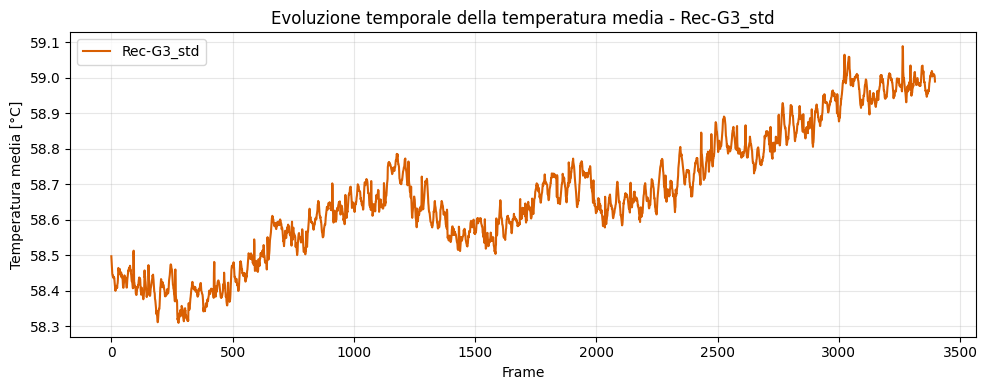

In [8]:
VIDEO_TO_PLOT = SELECTED_VIDEO
frames_plot = video_data[VIDEO_TO_PLOT]["frames"]

mean_values = frames_plot.mean(axis=(1, 2))   # (N,) media per frame

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mean_values, label=VIDEO_TO_PLOT, color="#d95f02", lw=1.5)
ax.set_xlabel("Frame")
ax.set_ylabel("Temperatura media [°C]")
ax.set_title(f"Evoluzione temporale della temperatura media - {VIDEO_TO_PLOT}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8 · Salvataggio frame come PNG (opzionale)

In [9]:
import cv2
from pathlib import Path

def save_frames_as_png(
    frames_raw: np.ndarray,
    output_dir: str,
    cmap_name: str = "inferno",
    global_min_value: float | None = None,
    global_max_value: float | None = None,
 ):
    """
    Salva i frame raw come PNG colorati normalizzando frame-by-frame.

    Evita di allocare un intero video uint8 in RAM.
    """
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    if global_min_value is None:
        global_min_value = float(frames_raw.min())
    if global_max_value is None:
        global_max_value = float(frames_raw.max())

    cmap = plt.get_cmap(cmap_name)

    for i, frame in enumerate(tqdm(frames_raw, desc=f"Salvataggio in {output_dir}")):
        frame_u8 = normalize_frame(frame, global_min_value, global_max_value)
        rgba = (cmap(frame_u8 / 255.0) * 255).astype(np.uint8)   # (H, W, 4)
        bgr = cv2.cvtColor(rgba[:, :, :3], cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(out_path / f"{i:04d}.png"), bgr)

    print(f"Salvati {len(frames_raw)} frame in: {out_path.resolve()}")

## Salvataggio immagini

In [10]:
# -- Salvataggio PNG disabilitato di default --
SAVE_PNG = True  # impostare a False per saltare il salvataggio PNG

BASE = Path(DATA_DIR)

if SAVE_PNG:
    for video_name in VIDEO_NAMES:
        save_frames_as_png(
            video_data[video_name]["frames"],
            str(BASE / f"{video_name}_frames"),
            cmap_name="inferno",
            global_min_value=global_min,
            global_max_value=global_max,
        )
else:
    print("Salvataggio PNG saltato (SAVE_PNG=False).")

Salvataggio in C:\Users\tomga\Desktop\ROI_study\Thermal_videos\Rec-G3_std_frames:   0%|          | 0/3397 [00:…

Salvati 3397 frame in: C:\Users\tomga\Desktop\ROI_study\Thermal_videos\Rec-G3_std_frames
